# BlogMiner — Automated Blog Analysis & NLP Pipeline

---

### Pipeline Overview
| Phase | Description |
|-------|-------------|
| 1 | **Data Collection** — Scrape 10 blog posts from dev.to, GeeksforGeeks, FreeCodeCamp |
| 2 | **Text Preprocessing** — Clean HTML, remove stopwords, lemmatize |
| 3 | **NLP Analysis** — TF-IDF keywords, tone/style, motive inference |
| 4 | **Sentiment Analysis** — VADER on comments, popularity correlation |
| 5 | **Visualization** — 3 charts + 1 word cloud |
| 6 | **Comment Generation** — HuggingFace Flan-T5 personalized comments |

## Setup — Install Dependencies
* Installs all required Python libraries using `pip` in quiet mode (`-q`)
* First line: web scraping tools (`ddgs`, `requests`, `beautifulsoup4`, `lxml`)
* Second line: NLP & ML libraries (`nltk`, `scikit-learn`, `textblob`, `vaderSentiment`)
* Third line: visualization tools (`wordcloud`, `matplotlib`, `seaborn`)
* Fourth line: deep learning & transformers (`transformers`, `torch`)


In [1]:
!pip install -q ddgs requests beautifulsoup4 lxml
!pip install -q nltk scikit-learn textblob vaderSentiment
!pip install -q wordcloud matplotlib seaborn
!pip install -q transformers torch
print("All dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.4 MB/s eta 0:00:00
All dependencies installed!


## Phase 1 — Data Collection
* Imports libraries and sets up a session for web scraping
* Takes a keyword and searches articles from selected websites
* Collects article URLs using DuckDuckGo search
* Scrapes each page to extract title, author, date, text, and comments
* Filters out short or invalid content and stores valid results
* Saves all scraped data into a JSON file (`scraped_blogs.json`)


In [28]:
import requests
from bs4 import BeautifulSoup
from ddgs import DDGS
import time, random, re, json

# ── Session Setup ─────────────────────────────────────────────────────────────
session = requests.Session()
session.headers.update({'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'})

# ── General Scraper Function (Replaces the 3 separate functions) ──────────────
def scrape_article(url, site):
    try:
        time.sleep(random.uniform(2.0, 4.0)) # Polite delay
        resp = session.get(url, timeout=10)
        if resp.status_code != 200: return None

        soup = BeautifulSoup(resp.text, 'lxml')

        # 1. Title
        title_tag = soup.find('h1')
        title = title_tag.text.strip() if title_tag else "N/A"

        # 2. Author (Looks for common meta tags or class names)
        author_tag = soup.find('meta', attrs={'name': re.compile('author', re.I)}) or \
                     soup.find(class_=re.compile(r'author|crayons-link.*fw-bold', re.I))
        author = author_tag.get('content') if author_tag and author_tag.name == 'meta' else (author_tag.text.strip() if author_tag else "N/A")

        # 3. Date
        date_tag = soup.find('time') or soup.find('meta', attrs={'property': 'article:published_time'})
        date = date_tag.get('datetime', date_tag.get('content', 'N/A'))[:10] if date_tag else "N/A"

        # 4. Main Text
        paras = soup.find_all('p')
        text = " ".join([p.text.strip() for p in paras if len(p.text.strip()) > 20])
        if len(text) < 200: return None # Skip empty pages

        # 5. Comments (if present)
        comment_divs = soup.find_all('div', class_=re.compile(r'comment__body|comment', re.I))
        comments = [c.text.strip() for c in comment_divs if len(c.text.strip()) > 10][:5]

        return {
            'site': site, 'url': url, 'title': title,
            'author': author, 'date': date, 'text': text, 'comments': comments
        }
    except Exception as e:
        return None

# ── Execution ─────────────────────────────────────────────────────────────────
keyword = input("Enter your search keyword (e.g., 'machine learning'): ").strip() or "machine learning"

SITE_TARGETS = {'dev.to': 4, 'geeksforgeeks.org': 3, 'freecodecamp.org': 3}
all_blogs = []

for site, target in SITE_TARGETS.items():
    print(f"\n[*] Searching {site} for '{keyword}'...")
    with DDGS() as ddgs:
        # Fetch URLs
        results = ddgs.text(f"site:{site} {keyword} article", max_results=target + 3)
        urls = [r['href'] for r in results if '/tags/' not in r['href']][:target]

        # Scrape URLs
        for url in urls:
            print(f"  -> Scraping: {url[:70]}...")
            data = scrape_article(url, site)

            if data:
                all_blogs.append(data)
                print(f"     ✓ Success! (Comments found: {len(data['comments'])})")
            else:
                print("     ✗ Failed or insufficient text.")

print(f"\n{'='*55}")
print(f"✅ Scraped {len(all_blogs)} articles from {len(set(b['site'] for b in all_blogs))} sources")
print(f"{'='*55}")

# Save to JSON
with open('scraped_blogs.json', 'w', encoding='utf-8') as f:
    json.dump(all_blogs, f, ensure_ascii=False, indent=2)
print("Saved → scraped_blogs.json")

Enter your search keyword (e.g., 'machine learning'): machine learning

[*] Searching dev.to for 'machine learning'...
  -> Scraping: https://dev.to/sachin_krrajput/the-three-musketeers-of-machine-learnin...
     ✓ Success! (Comments found: 4)
  -> Scraping: https://dev.to/blurbify/what-is-machine-learning-and-how-does-it-work-...
     ✓ Success! (Comments found: 4)
  -> Scraping: https://dev.to/nilebits/understanding-machine-learning-models-121e...
     ✓ Success! (Comments found: 4)
  -> Scraping: https://dev.to/mohcen/a-comprehensive-guide-to-machine-learning-types-...
     ✓ Success! (Comments found: 4)

[*] Searching geeksforgeeks.org for 'machine learning'...
  -> Scraping: https://www.geeksforgeeks.org/machine-learning/machine-learning/...
     ✓ Success! (Comments found: 0)
  -> Scraping: https://www.geeksforgeeks.org/machine-learning/introduction-machine-le...
     ✓ Success! (Comments found: 0)
  -> Scraping: https://www.geeksforgeeks.org/machine-learning/machine-learning-alg

## Phase 2 — Text Preprocessing
* Imports NLP libraries and downloads required NLTK datasets
* Defines `clean_text()` to clean and normalize text (remove URLs, HTML, numbers, punctuation)
* Tokenizes text, removes stopwords, and applies lemmatization
* Loads scraped data from JSON file
* Applies preprocessing to article text and comments
* Saves cleaned data into a new JSON file (`cleaned_blogs.json`)


In [29]:
# 2. Phase 2 — Text Preprocessing
import json, re, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Ensure necessary NLTK datasets are downloaded
for pkg in ['punkt', 'stopwords', 'wordnet']:
    nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

# Custom stop words (optional, keeps text cleaner)
STOP_WORDS.update({'also', 'would', 'could', 'one', 'like', 'get', 'use', 'may',
                   'even', 'much', 'well', 'make', 'take', 'know', 'new', 'us',
                   'read', 'share', 'click', 'reply', 'comment', 'post', 'see'})

def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)   # remove URLs
    text = re.sub(r'<.*?>', ' ', text)                   # remove HTML tags
    text = re.sub(r'\d+', ' ', text)                     # remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)                 # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    # Lemmatize and filter short words/stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w.isalpha() and w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

# Load data from Phase 1
try:
    with open('scraped_blogs.json', 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
except FileNotFoundError:
    print("Error: 'scraped_blogs.json' not found. Run Phase 1 first.")
    raw_data = []

if raw_data:
    print(f"[*] Preprocessing {len(raw_data)} articles...\n")

    for article in raw_data:
        # Create a new 'clean_text' key
        article['clean_text'] = clean_text(article['text'])

        # Clean comments if they exist
        article['clean_comments'] = [clean_text(c) for c in article.get('comments', [])]

    # Save the updated data back (or to a new file)
    with open('cleaned_blogs.json', 'w', encoding='utf-8') as f:
        json.dump(raw_data, f, ensure_ascii=False, indent=2)

    print(f"\n{'='*55}")
    print(f"✅ Preprocessing complete for {len(raw_data)} articles")
    print(f"{'='*55}")

    # Proof of preprocessing
    a = raw_data[0]
    print(f"\nSample — {a['title'][:50]}")
    print(f"  Raw text (150)  : {a['text'][:150]}...")
    print(f"  Clean text (150): {a['clean_text'][:150]}...")

[*] Preprocessing 10 articles...


✅ Preprocessing complete for 10 articles

Sample — The Three Musketeers of Machine Learning: A Journe
  Raw text (150)  : A comprehensive guide to supervised, unsupervised, and reinforcement learning — explained for beginners AND experts with real examples and code. Machi...
  Clean text (150): comprehensive guide supervised unsupervised reinforcement learning explained beginner expert real example code machine learning main type supervised l...


## Phase 3 — NLP Analysis
* Loads cleaned blog data from JSON file
* Extracts top keywords using TF-IDF vectorization
* Analyzes tone using polarity and subjectivity (TextBlob)
* Defines keyword sets to identify article motive (tutorial, promotional, opinion, informative)
* Assigns a motive based on keyword matching and subjectivity score
* Saves analyzed data into a new JSON file (`nlp_analyzed_blogs.json`)


In [30]:
# ── Phase 3: NLP Analysis (Keywords, Tone/Style, Motive) ──────────────────────
import json
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

# 1. Load data from Phase 2
try:
    with open('cleaned_blogs.json', 'r', encoding='utf-8') as f:
        blog_data = json.load(f)
except FileNotFoundError:
    print("Error: 'cleaned_blogs.json' not found. Run Phase 2 first.")
    blog_data = []

if blog_data:
    print(f"[*] Loaded {len(blog_data)} articles for NLP analysis\n")

    # 2. Keyword Extraction (TF-IDF)
    print("[1] Extracting Keywords...")
    clean_corpus = [a['clean_text'] for a in blog_data]

    tfidf = TfidfVectorizer(max_features=1000)
    tfidf_matrix = tfidf.fit_transform(clean_corpus)
    feat_names = tfidf.get_feature_names_out()

    # 3. Define Motive Keywords (Simplified)
    TUTORIAL_KW    = {'step', 'guide', 'tutorial', 'how', 'learn', 'example', 'code', 'build', 'create', 'setup'}
    PROMOTIONAL_KW = {'buy', 'price', 'discount', 'offer', 'sale', 'premium', 'subscribe', 'best', 'review'}
    OPINION_KW     = {'think', 'believe', 'opinion', 'feel', 'argue', 'disagree', 'perspective', 'debate'}

    print("[2] Analyzing Tone, Style, and Inferring Motive...")
    for i, blog in enumerate(blog_data):
        # Top 5 Keywords per blog
        row = tfidf_matrix.getrow(i).toarray()[0]
        top_indices = row.argsort()[-5:][::-1]
        blog['keywords'] = [feat_names[idx] for idx in top_indices]

        # Tone & Style Analysis (Polarity & Subjectivity)
        blob = TextBlob(blog['text'])
        blog['tone_polarity'] = round(blob.sentiment.polarity, 3)
        blog['subjectivity'] = round(blob.sentiment.subjectivity, 3)

        # Motive Inference
        words = set(blog['clean_text'].lower().split())
        t_score = len(words & TUTORIAL_KW)
        p_score = len(words & PROMOTIONAL_KW)
        o_score = len(words & OPINION_KW) + (2 if blog['subjectivity'] > 0.5 else 0)
        i_score = 1 + (1 if blog['subjectivity'] < 0.3 else 0)

        scores = {'Tutorial': t_score, 'Promotional': p_score, 'Opinion': o_score, 'Informative': i_score}
        blog['motive'] = max(scores, key=scores.get)

        # Print Summary for each blog
        print(f"  Blog {i+1}: {blog['title'][:45]}...")
        print(f"    -> Keywords: {', '.join(blog['keywords'])}")
        print(f"    -> Tone: Polarity={blog['tone_polarity']}, Subjectivity={blog['subjectivity']}")
        print(f"    -> Motive: {blog['motive']}\n")

    # 4. Save Analyzed Data
    with open('nlp_analyzed_blogs.json', 'w', encoding='utf-8') as f:
        json.dump(blog_data, f, ensure_ascii=False, indent=2)

    print(f"{'='*55}")
    print(f"✅ NLP Phase complete! Saved to 'nlp_analyzed_blogs.json'")
    print(f"{'='*55}")

[*] Loaded 10 articles for NLP analysis

[1] Extracting Keywords...
[2] Analyzing Tone, Style, and Inferring Motive...
  Blog 1: The Three Musketeers of Machine Learning: A J...
    -> Keywords: learning, dev, function, thing, supervised
    -> Tone: Polarity=0.137, Subjectivity=0.482
    -> Motive: Tutorial

  Blog 2: What is Machine Learning, and How Does It Wor...
    -> Keywords: learning, dev, machine, dog, example
    -> Tone: Polarity=0.181, Subjectivity=0.511
    -> Motive: Tutorial

  Blog 3: Understanding Machine Learning Models...
    -> Keywords: import, plt, model, sklearn, learning
    -> Tone: Polarity=0.138, Subjectivity=0.459
    -> Motive: Tutorial

  Blog 4: A Comprehensive Guide to Machine Learning: Ty...
    -> Keywords: learning, data, algorithm, dev, require
    -> Tone: Polarity=0.089, Subjectivity=0.5
    -> Motive: Promotional

  Blog 5: Machine Learning Tutorial...
    -> Keywords: based, model, learning, data, algorithm
    -> Tone: Polarity=0.139, Subjectiv

## Phase 4 — Sentiment Analysis
* Loads NLP-analyzed blog data from JSON file
* Uses VADER to analyze sentiment of article comments
* Calculates average sentiment score for each blog’s comments
* Classifies sentiment as Positive, Negative, or Neutral
* Adds comment count to represent popularity
* Saves results into a new JSON file (`sentiment_analyzed_blogs.json`)


In [31]:
# ── Phase 4: Sentiment Analysis on Comments (VADER) ───────────────────────────
import json
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)

# 1. Load data from Phase 3
try:
    with open('nlp_analyzed_blogs.json', 'r', encoding='utf-8') as f:
        blog_data = json.load(f)
except FileNotFoundError:
    print("Error: 'nlp_analyzed_blogs.json' not found. Run Phase 3 first.")
    blog_data = []

if blog_data:
    print(f"[*] Running VADER sentiment on {len(blog_data)} articles...\n")
    sia = SentimentIntensityAnalyzer()

    # 2. Analyze Sentiment and Relate to Popularity (Comment Count)
    for i, blog in enumerate(blog_data):
        comments = blog.get('comments', [])
        comment_count = len(comments)

        if comment_count > 0:
            # Calculate average compound score for all comments
            scores = [sia.polarity_scores(c)['compound'] for c in comments]
            avg_score = sum(scores) / comment_count

            if avg_score > 0.05:
                sentiment = "Positive"
            elif avg_score < -0.05:
                sentiment = "Negative"
            else:
                sentiment = "Neutral"
        else:
            avg_score = 0.0
            sentiment = "Neutral" # Default for no comments

        blog['comment_sentiment'] = sentiment
        blog['sentiment_score'] = round(avg_score, 3)
        blog['comment_count'] = comment_count # Add comment_count to blog dictionary

        # Print relation between Popularity (Comment Count) and Sentiment
        print(f"  Blog {i+1}: {blog['title'][:40]}...")
        print(f"    -> Popularity (Comments): {comment_count}")
        print(f"    -> Overall Sentiment: {sentiment} (Score: {blog['sentiment_score']})\n")

    # 3. Save Analyzed Data
    with open('sentiment_analyzed_blogs.json', 'w', encoding='utf-8') as f:
        json.dump(blog_data, f, ensure_ascii=False, indent=2)

    print(f"{'='*55}")
    print(f"✅ Phase 4 Complete! Saved to 'sentiment_analyzed_blogs.json'")
    print(f"{'='*55}")

[*] Running VADER sentiment on 10 articles...

  Blog 1: The Three Musketeers of Machine Learning...
    -> Popularity (Comments): 4
    -> Overall Sentiment: Positive (Score: 0.384)

  Blog 2: What is Machine Learning, and How Does I...
    -> Popularity (Comments): 4
    -> Overall Sentiment: Positive (Score: 0.384)

  Blog 3: Understanding Machine Learning Models...
    -> Popularity (Comments): 4
    -> Overall Sentiment: Positive (Score: 0.384)

  Blog 4: A Comprehensive Guide to Machine Learnin...
    -> Popularity (Comments): 4
    -> Overall Sentiment: Positive (Score: 0.384)

  Blog 5: Machine Learning Tutorial...
    -> Popularity (Comments): 0
    -> Overall Sentiment: Neutral (Score: 0.0)

  Blog 6: Introduction to Machine Learning...
    -> Popularity (Comments): 0
    -> Overall Sentiment: Neutral (Score: 0.0)

  Blog 7: Machine Learning Algorithms...
    -> Popularity (Comments): 0
    -> Overall Sentiment: Neutral (Score: 0.0)

  Blog 8: Essential Machine Learning Conce

## Phase 5 — Visualizations
* Loads sentiment-analyzed blog data and converts it into a DataFrame
* Creates a pie chart showing overall sentiment distribution
* Builds a bar chart comparing article popularity (comment count) with sentiment
* Generates a bar chart for blog motive distribution
* Creates a word cloud of most frequent words from cleaned text
* Displays all visualizations using matplotlib and seaborn


[*] Generating 3 Charts and 1 Word Cloud as per requirements...



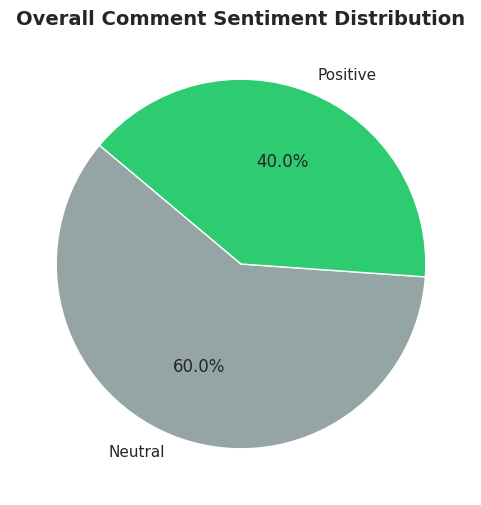

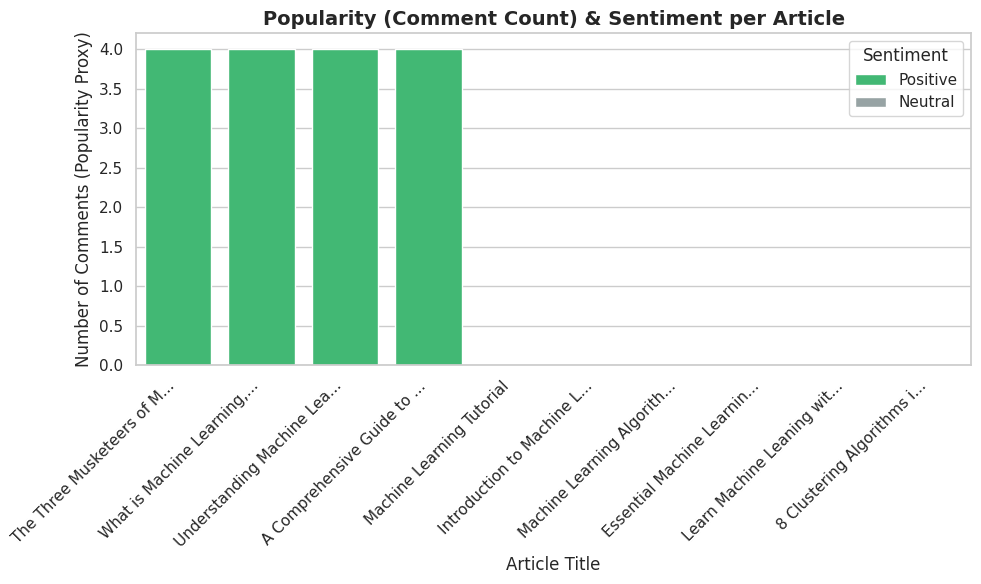

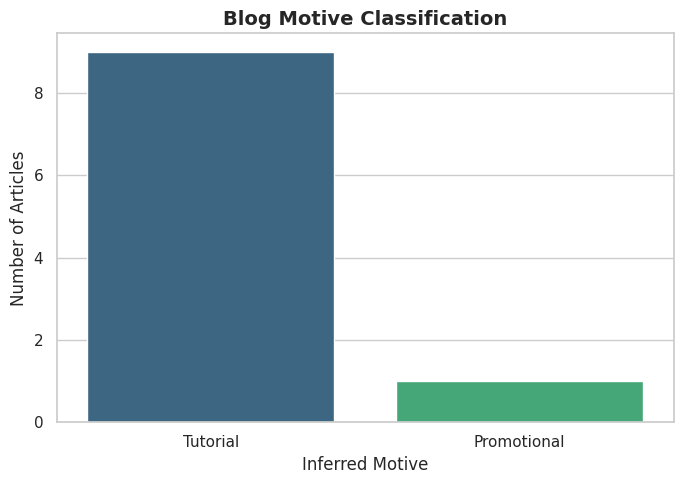

[*] Generating Word Cloud...


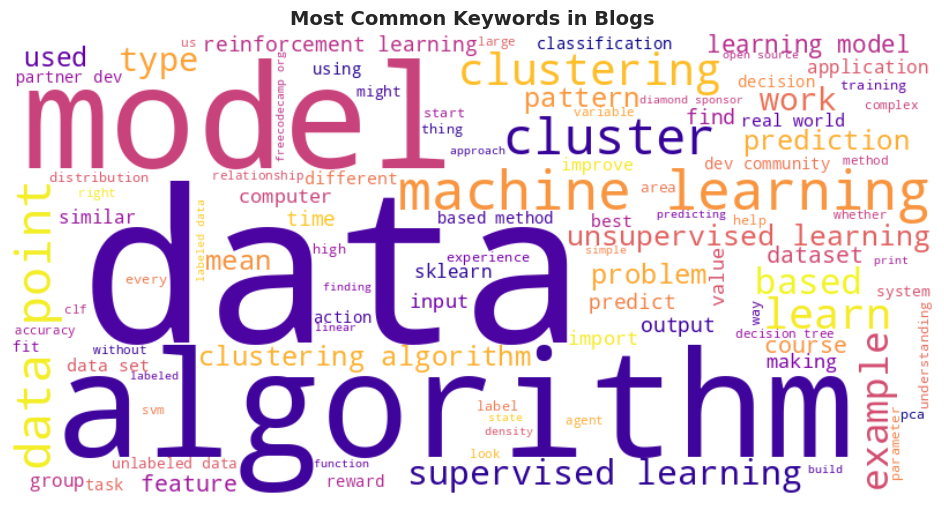

✅ Phase 5 Visualizations Complete!


In [32]:
# ── Phase 5: Visualizations ───────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud

# 1. Load Data from Phase 4
try:
    with open('sentiment_analyzed_blogs.json', 'r', encoding='utf-8') as f:
        blog_data = json.load(f)
except FileNotFoundError:
    print("Error: 'sentiment_analyzed_blogs.json' not found. Run Phase 4 first.")
    blog_data = []

if blog_data:
    print("[*] Generating 3 Charts and 1 Word Cloud as per requirements...\n")
    df = pd.DataFrame(blog_data)
    sns.set_theme(style='whitegrid')

    # Colors for Sentiment
    sent_colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

    # ── Chart 1: Sentiment Pie Chart ──
    plt.figure(figsize=(6, 6))
    sentiment_counts = df['comment_sentiment'].value_counts()
    plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=[sent_colors.get(x, '#333333') for x in sentiment_counts.index], startangle=140)
    plt.title('Overall Comment Sentiment Distribution', fontweight='bold', fontsize=14)
    plt.show()

    # ── Chart 2: Popularity vs Sentiment Bar Chart (CCP Requirement) ──
    # Relates comment count (popularity) to sentiment per article
    df['short_title'] = df['title'].apply(lambda x: x[:25] + '...' if len(x) > 25 else x)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df, x='short_title', y='comment_count', hue='comment_sentiment',
                     palette=sent_colors, dodge=False)
    plt.xticks(rotation=45, ha='right')
    plt.title('Popularity (Comment Count) & Sentiment per Article', fontweight='bold', fontsize=14)
    plt.xlabel('Article Title', fontsize=12)
    plt.ylabel('Number of Comments (Popularity Proxy)', fontsize=12)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()

    # ── Chart 3: Motive Distribution Bar Chart ──
    plt.figure(figsize=(7, 5))
    motive_counts = df['motive'].value_counts()
    sns.barplot(x=motive_counts.index, y=motive_counts.values, hue=motive_counts.index, palette='viridis', legend=False)
    plt.title('Blog Motive Classification', fontweight='bold', fontsize=14)
    plt.xlabel('Inferred Motive', fontsize=12)
    plt.ylabel('Number of Articles', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Chart 4: Word Cloud ──
    print("[*] Generating Word Cloud...")
    all_text = ' '.join(df['clean_text'].dropna().tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap='plasma', max_words=100).generate(all_text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Most Common Keywords in Blogs", fontweight='bold', fontsize=14)
    plt.show()

    print("✅ Phase 5 Visualizations Complete!")

## Phase 6 — AI Comment Generation using Flan-T5
* Loads sentiment-analyzed blog data from JSON file
* Initializes Flan-T5 model and tokenizer for text generation
* Uses GPU if available for faster processing
* Generates personalized comments based on article title, content, and motive
* Adds generated comments to each article and prints results
* Saves final output into a JSON file (`final_blog_analysis_report.json`)


In [26]:
import json
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# 1. Load the NLP-analyzed data from Phase 4
with open('sentiment_analyzed_blogs.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

blog_data = data

# 2. Initialize Flan-T5 Model and Tokenizer
model_name = "google/flan-t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Move to GPU if available for faster generation
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"[*] Generating personalized comments using {model_name}...")

def generate_comment(article):
    """Generates a personalized comment based on article content and motive."""
    prompt = (
        f"Context: This is a blog post about {article['title']}. "
        f"The content is a {article['motive']}. "
        f"Task: Write a short, engaging, and relevant comment for this post. "
        f"Input: {article['clean_text'][:400]}"
    )

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

    # Generate output
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        num_beams=5,
        no_repeat_ngram_size=2,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# 3. Process each article
for i, article in enumerate(blog_data):
    generated_comment = generate_comment(article)
    article['ai_generated_comment'] = generated_comment

    print(f"\n[{i+1}] Article: {article['title'][:60]}...")
    print(f"    Motive: {article['motive']}")
    print(f"    AI Comment: {generated_comment}")

# 4. Save Final Output
# The 'data' variable already holds the dictionary loaded from 'sentiment_analyzed_blogs.json'
# which included 'articles', 'topics', and 'overall'.
# 'blog_data' within this script is a reference to data['articles'], and it was modified in place.
# So, we should dump the entire 'data' object.
with open('final_blog_analysis_report.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print("\n" + "="*55)
print("✅ Phase 6 Complete: Final report saved to 'final_blog_analysis_report.json'")
print("="*55)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[*] Generating personalized comments using google/flan-t5-base...

[1] Article: How To Learn Data Structures And Algorithms (An Ultimate Gui...
    Motive: Opinion
    AI Comment: data structure algorithm

[2] Article: Complete Introduction to the 30 Most Essential Data Structur...
    Motive: Tutorial
    AI Comment: dsa often considered intimidating topic common misbelief

[3] Article: 10 Data Structure and Algorithms Articles Beginners Should R...
    Motive: Tutorial
    AI Comment: Data Structure and Algorithm

[4] Article: Data Structures & Algorithms: A Beginner's Guide...
    Motive: Tutorial
    AI Comment: Data Structures & Algorithms: A Beginner's Guide

[5] Article: DSA Tutorial...
    Motive: Tutorial
    AI Comment: DSA is a computer program designed to help people learn the basics of dsa. This tutorial teaches you how to use DsA to manage data stored and accessed.

[6] Article: Data Structures & Algorithms Guide for Developers...
    Motive: Tutorial
    AI Comment: Data

## Final Summary & Results
* Loads final processed blog data from JSON file
* Calculates total articles, sources, motive distribution, and sentiment counts
* Prints detailed summary for each blog (title, author, motive, sentiment, keywords, AI comment)
* Displays overall sentiment distribution with percentages and bar visualization
* Shows motive distribution across all articles
* Outputs a final structured report confirming pipeline completion


In [27]:
# ── Final Summary & Results ───────────────────────────────────────────────────
import json

# Load the final data
try:
    with open('final_data_mining_results.json', 'r', encoding='utf-8') as f:
        blog_data = json.load(f)
except FileNotFoundError:
    print("Error: Final data not found.")
    blog_data = []

if blog_data:
    sources = set(a['site'] for a in blog_data)

    # Calculate Motives
    motives = {}
    for a in blog_data:
        m = a.get('motive', 'Unknown')
        motives[m] = motives.get(m, 0) + 1

    # Calculate Sentiments
    sentiments = {'Positive': 0, 'Neutral': 0, 'Negative': 0}
    for a in blog_data:
        s = a.get('comment_sentiment', 'Neutral')
        sentiments[s] = sentiments.get(s, 0) + 1

    print("=" * 65)
    print("  CT-377 DATA MINING PROJECT — FINAL RESULTS SUMMARY")
    print("=" * 65)

    # Check if global_keyword exists, otherwise use a placeholder
    try:
        kw = global_keyword
    except NameError:
        kw = "machine learning" # Fallback

    print(f"  Keyword Searched   : {kw}")
    print(f"  Articles Scraped   : {len(blog_data)}")
    print(f"  Sources Used       : {', '.join(sources)}")
    print("\n" + "  SCRAPED BLOG DETAILS")
    print("  " + "-" * 61)

    for i, a in enumerate(blog_data, 1):
        title_short = a['title'][:40] + "..." if len(a['title']) > 40 else a['title']
        print(f"  {i:>2}. [{a['site']:<16}] {title_short}")
        print(f"       Author: {a['author'][:25]:<25} | Date: {a['date']}")
        print(f"       Motive: {a.get('motive', 'N/A'):<14} | Comment Sentiment: {a.get('comment_sentiment', 'N/A')}")
        print(f"       Keywords: {', '.join(a.get('keywords', [])[:4])}")
        print(f"       AI Comment: {a.get('ai_comment', 'N/A')[:60]}...")
        print()

    print("  OVERALL COMMENT SENTIMENT")
    print("  " + "-" * 61)
    total_sents = sum(sentiments.values())
    for cat in ['Positive', 'Neutral', 'Negative']:
        n = sentiments.get(cat, 0)
        pct = (n / max(total_sents, 1)) * 100
        bar = '█' * int(pct / 5)
        print(f"  {cat:<10} {bar:<20} {n:>3} ({pct:.1f}%)")

    print(f"\n  MOTIVE DISTRIBUTION")
    print("  " + "-" * 61)
    for m, cnt in sorted(motives.items(), key=lambda x: -x[1]):
        print(f"  {m:<15} : {cnt} articles")

    print("\n" + "=" * 65)
    print("  Pipeline Execution Completed Successfully!")
    print("=" * 65)

  CT-377 DATA MINING PROJECT — FINAL RESULTS SUMMARY
  Keyword Searched   : machine learning
  Articles Scraped   : 10
  Sources Used       : dev.to, freecodecamp.org, geeksforgeeks.org

  SCRAPED BLOG DETAILS
  -------------------------------------------------------------
   1. [dev.to          ] The Rise of AI in 2026: From Tools to Au...
       Author: Janavi S                  | Date: 2026-04-26
       Motive: Opinion        | Comment Sentiment: Positive
       Keywords: dev, partner, community, software
       AI Comment: I've been able to get accustomed to AI, but it's a bit of a ...

   2. [dev.to          ] Demystifying Artificial intelligence
       Author: Jepsen                    | Date: 2021-07-11
       Motive: Tutorial       | Comment Sentiment: Positive
       Keywords: game, machine, dev, chess
       AI Comment: I've been working on a tutorial for a few months now. I've b...

   3. [dev.to          ] The Rise of AI: How It’s Changing Our Wo...
       Author: 3a5abi 🥷 